<a href="https://colab.research.google.com/github/samyfs-DA/telecom-analysis/blob/main/s7_version_estudiante_project_connectatel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
!git clone https://github.com/samyfs-DA/telecom-analysis.git

Cloning into 'telecom-analysis'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 30 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 1.09 MiB | 6.54 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('telecom-analysis/plans.csv')
users = pd.read_csv('telecom-analysis/users_latam.csv') #completa el código
usage = pd.read_csv('telecom-analysis/usage.csv') #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('Cantidad de nulos en users:\n', users.isna().sum()) # Cantidad de valores nulos)
print('Proporción de valores nulos en users:\n', users.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos)

Cantidad de nulos en users:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos en users:
 churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
age           0.00000
last_name     0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print('Cantidad de nulos en usage:\n', usage.isna().sum()) # Cantidad de valores nulos)
print('Proporción de valores nulos en usage:\n', usage.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos)

Cantidad de nulos en usage:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos en usage:
 duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?<br> - Para el dataset de **users** nos encontramos con dos columnas que tienen valores faltantes o nulos, los cuales son `churn_date` con un 88% y el segundo es `city` con un 11%. <br> - Para el dataset **usage** nos encontramos con tres columnas que tienen valores faltantes o nulos, las cuales son `duration` con un 55%, `lenght` con un 44% y `date` con un 0.12%
  
- Indica qué harías: ¿imputar, eliminar, ignorar <br> - Con base a las preguntas del negocio y que no son columnas relevantes para este análisis  se ignoran dentro del datase **users** `churn_date`.<br> - Dado que se consideran que impactan al análisis, se investigará para imputar dentro del dataset **users** `city`, y dentro del dataset **usage** `duration`, `lenght`. Por otro lado se revisará si es viable realizar la imputación o bien dejar como nulos dentro del dataset **usage** la  columna `date`, dado que al momento no se considera parte del análisis, sin embargo esto puede cambiar conforme se anvence en éste análisis o exista alguna otra pregunta para el negocio que sea importante.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se observa que muestra un comportamiento simétrico dado que el 50%, también conocida como mediana y el promedio (mean) son iguales.
- La columna `age` se observa que contamos con un "sentinels" (-999) que está provocando un valor atípico en *min*, se puede observar una distribución al momento casi simétrica, esto se corroborará más adelante una vez que se realice limpieza del dataset.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna `id` se observa una distribución normal, esto se determina porque el promedio (mean) y la mediana (cuadril 50%) son iguales, mientras que en `user_id` es casi normal, los números no son iguales, son cercanos, esto podría deberse a que en el dataset podríamos encontrar el mismo *user_id* repetido, sin embargo, no significa que se éste tratando del mis evento, recordemos que el dataset registra los eventos de llamadas y mensajes, se verificara más adelante conforme se limpien los datos.
- Las columnas `duration` y `length` no contamos con todos los datos y como se ha revisado contamos con valores faltantes y nulos que no nos permiten indicar el comportamiento estadístico, contamos con sesgos de información y esto nos hace interpretar una distribución casí normal.

In [ ]:
# explorar columnas categóricas de users
print(users['city'].unique())
print(users['plan'].unique())
print(users['city'].value_counts())
print(users['plan'].value_counts())
users[['city', 'plan']].nunique().sort_values()

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


,0
plan,2
city,7


- La columna `city` podemos observar que tiene un "sentinel" `?` y valores vacíos `NaN`, por lo que se revisará cómo se tratarán estos valores.
- La columna `plan` se cuenta con los datos correctos y completos no hay faltantes ni sentinels

In [ ]:
# explorar columna categórica de usage
print(usage['type'].unique())
usage['type'].value_counts() # completa el código

['call' 'text']


,count
type,
text,22092
call,17908


- La columna `type` se cuenta con todos los registros sin sentinels o valores nulos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?<br> Dentro del dataset *users* se observó que se tiene el `sentinel` **-999** en la columna `age` y que se tienen tanto `valores faltantes` **NaN** y `sentinels` **"?"** en la comuna `city` , en el dataset *usage* se observo que en las columnas `duration` y `length` tenemos faltantes de información.
- ¿Qué acción tomarías?<br> *users* -> `age` se imputará con la mediana, dado que es el valor más adecuado porque el promedio (mean) se encuentra alterado por el el sentinel. <br> *users* -> `city` se imputará conforme indique el negocio, dado que imputar por moda puede provocar un sesgo en el análisis. <br> *user* -> `duration` y `length`se reuqiere un análsis mas profundo dado que por lo observado que duration va ligado cuando se hace referencia a que el usario hace una llamada, mientras length hace referencia cuando el usario envía un texto, y no necesariament se debe contar con valores en cada columna.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Revisión de posibles errores:
prueb=pd.to_datetime(users['reg_date'], errors='coerce')
users[prueb.isna()]['reg_date']

,reg_date


In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [ ]:
prueba=pd.to_datetime(usage['date'], errors='coerce')
usage[prueba.isna()]['date']

,date
2854,NaN
3443,NaN
3808,NaN
3987,NaN
4114,NaN
6287,NaN
6445,NaN
6584,NaN
7879,NaN
8204,NaN


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

,reg_date
count,4000
mean,2023-07-14 07:31:29.284321280
min,2022-01-01 00:00:00
25%,2022-10-05 14:00:10.802700800
50%,2023-07-09 21:26:03.690922752
75%,2024-04-11 15:43:20.750187520
max,2026-05-10 00:00:00


En `reg_date`, presenta un total de 3,961 registros unicos, y se observa que la fecha 2026-05-10 es el que tiene 40 registros, si embargo, usuarios previos a esta fecha quedaran fuera del analisis, dado que se evalura registros hasta 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

,date
count,39950
mean,2024-03-31 11:58:45.887006208
min,2024-01-01 00:00:00
25%,2024-02-15 05:56:44.515112960
50%,2024-03-31 12:06:30.969774336
75%,2024-05-15 18:09:46.454661376
max,2024-06-30 00:00:00


En `date`, en esta columna nos encontramos solo fechas de interes (2024), dado que como el nombre del dataset indica se trata del comportamiento de los usarios.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso: <br> Con base a la información revisada se observa que el dataset de *users* cuenta con información desde 2021 hasta 2026, se deberá revisar cuantos usarios que se registraron durante 2024 aparecen en el dataset *usage* que nos da el comportamiento de uso durante el año 2024. <br> En el dataset *usage* se observa que se trata de un periodo corto de 2024, sin embargo, pueden existir valores nulos por la conversión y esto puede afectar la cantidad final de datos que se van a revisar.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)<br> En el dataset *users* si contamos con registros desde 2021, y la última fecha es de 2026 y que al momento de realizar este ejercicio nos encontramos en junio de 2026, por lo cual no se considera una fecha imposible o que no ha transucurrido; por otro lado en el dataset de *usage* no encontramos mayor información o años dierentes a 2024.
- ¿Qué harías con ellas? <br> Se deberá realizar un filtrado de usuarios activos dentro *usage* para poder responder las preguntas del negocio.
  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.122250
std,17.690408
min,18.000000
25%,33.000000
50%,47.000000
75%,63.000000
max,79.000000


In [ ]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace("?", pd.NA)

# Verificar cambios
print(users['city'].unique())
users['city'].describe()

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


,city
count,3435
unique,6
top,Bogotá
freq,808


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp('2024-12-31'), 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

,reg_date
count,3960
mean,2023-07-03 21:39:41.095273728
min,2022-01-01 00:00:00
25%,2022-10-02 20:17:11.657914368
50%,2023-07-04 10:00:05.401350400
75%,2024-04-03 04:00:05.401350400
max,2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values()

,duration
type,
call,0.000000
text,0.999276


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values()

,length
type,
text,0.00000
call,0.99933


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se ha revisado y ambas columnas son del tipo **MAR** debido a que en el momento que se produce un evento de llamada se tienen registros en `duration` y cuando se esta enviando un mensaje de texto se tiene registros en `length` es por ello que no se pueden ni imputar ni eliminar, se deben de conservar como estan.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    total_mensajes=('is_text','sum'),
    total_llamadas=('is_call','sum'),
    total_minutos=('duration','sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'total_mensajes':'cant_mensajes', 'total_llamadas':'cant_llamadas', 'total_minutos':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =pd.merge(usage_agg, users, on=['user_id'], how='inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada', 'age']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].describe()

,plan
count,3999
unique,2
top,Basico
freq,2594


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

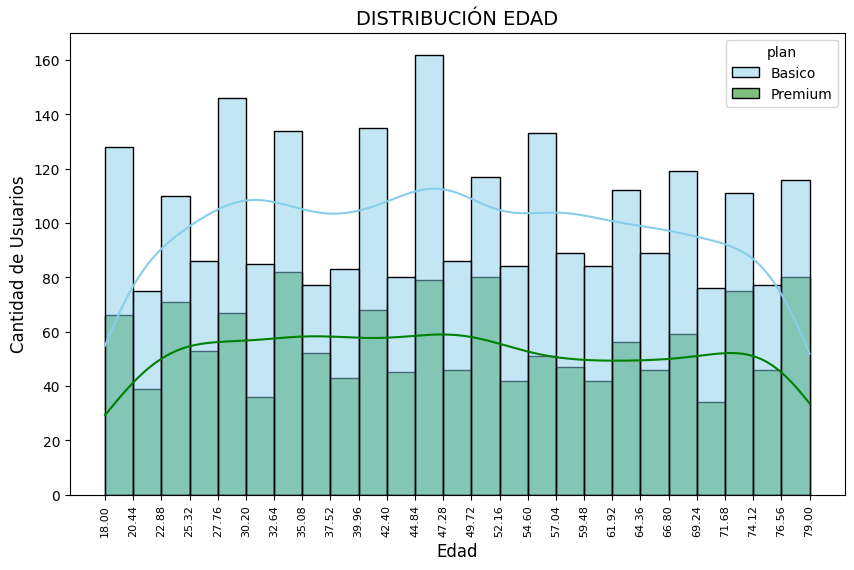

In [ ]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='age', hue='plan', bins=25, palette=['skyblue','green'], kde=True)
bin_edge = np.histogram_bin_edges(user_profile['age'], bins=25)
plt.xticks(bin_edge, rotation=90, fontsize=8)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.title('DISTRIBUCIÓN EDAD', fontsize=14)
plt.show()

💡Insights:
- **Distribución en plan basico** de del tipo picuda, se observa una baja variabilidad y que la mayoría de los valores se encuentra en el rango entre 44.89 y 47.28.
- **Distribución en plan premium** es del tipo aplanada, se observa una alta variabilidad, es decir, los valaores están repartidos en varios rangos.
- No se observa sesgos, ni valores atípicos en esta histograma.

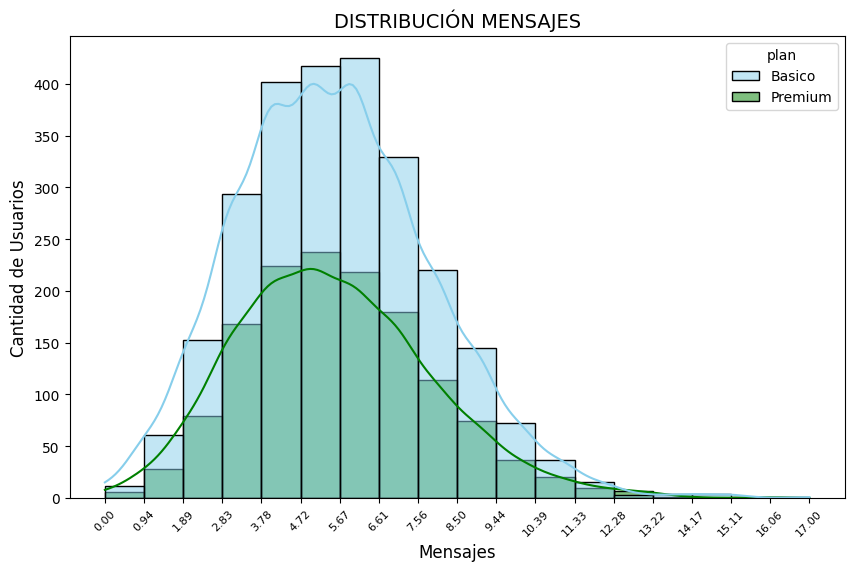

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=18, palette=['skyblue','green'], kde=True)
bin_edge = np.histogram_bin_edges(user_profile['cant_mensajes'], bins=18)
plt.xticks(bin_edge, rotation=45, fontsize=8)
plt.xlabel('Mensajes', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.title('DISTRIBUCIÓN MENSAJES', fontsize=14)
plt.show()

💡Insights:
- **Distribución en el plan básico** es del tipo multimodal, en la parte central (rango 3.78 a 6.61), se identifica los rangos donde se agrupan la mayor cantidad de mensajes.
- **Distribución en el plan preimum** es del tipo picuda, se conentran la mayoría de los valores entre el rengo 4.72 y 5.67.
- Ambos planes muestran un sesgo hacia la derecha donde se encuentran el valor más alto.

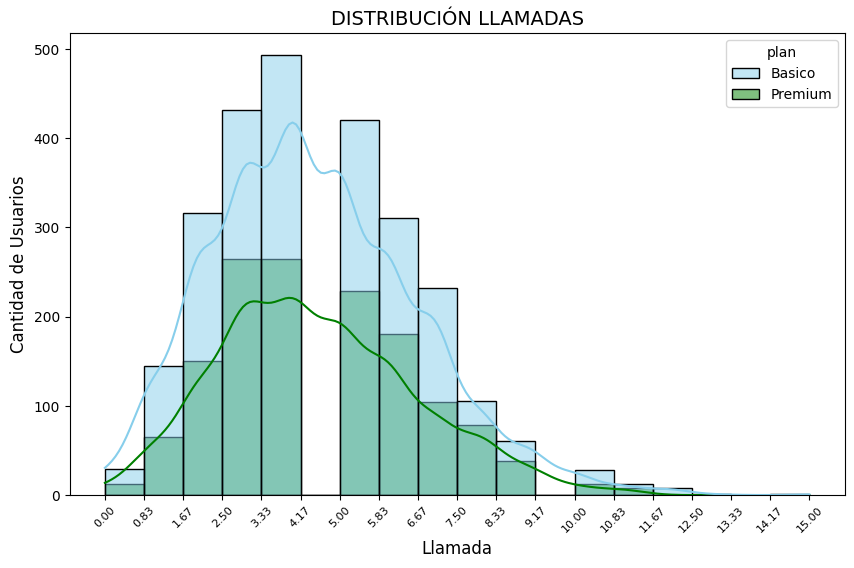

In [ ]:
# Histograma para visualizar) la cant_llamadas
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=18, palette=['skyblue','green'], kde=True)
bin_edge = np.histogram_bin_edges(user_profile['cant_llamadas'], bins=18)
plt.xticks(bin_edge, rotation=45, fontsize=8)
plt.xlabel('Llamada', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.title('DISTRIBUCIÓN LLAMADAS', fontsize=14)
plt.show()

💡Insights:
- **Distribución en el plan básico** es del tipo multimodal, en la parte central (rango 2.50 a 4.17), se identifica los rangos donde se agrupan la mayor cantidad de llamadas.
- **Distribución en el plan preimum** es del tipo con tendecia aplanada, se observa un pequeño pico en el rango 3.33 y 4.17.
- Ambos planes muestran un sesgo hacia la derecha donde se encuentran el valor más alto.

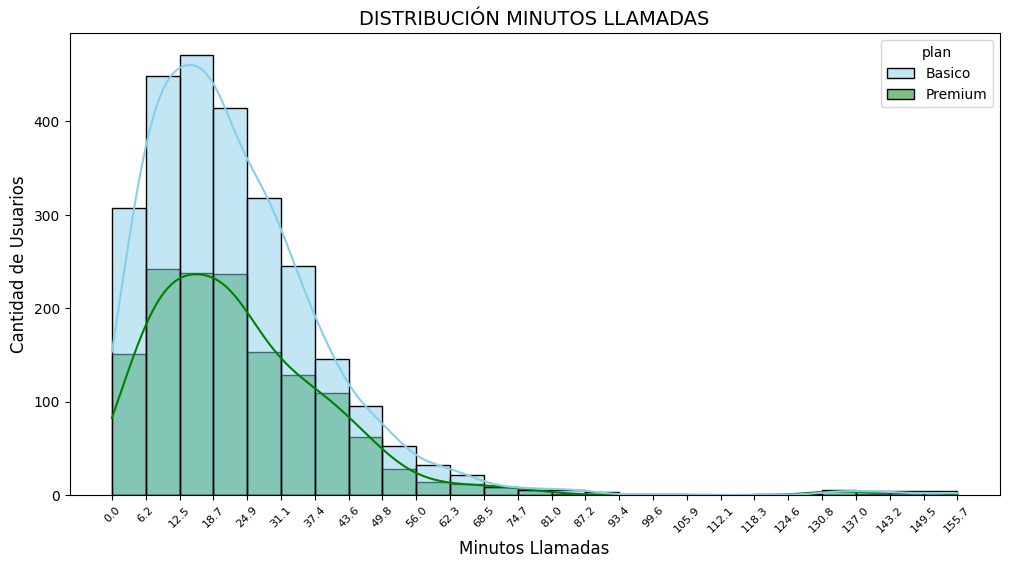

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(12,6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=25, palette=['skyblue','green'], kde=True)
bin_edge = np.histogram_bin_edges(user_profile['cant_minutos_llamada'], bins=25)
plt.xticks(bin_edge, rotation=45, fontsize=8)
plt.xlabel('Minutos Llamadas', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.title('DISTRIBUCIÓN MINUTOS LLAMADAS', fontsize=14)
plt.show()

💡Insights:
- **Distribución plan básico y premium** es del tipo picudo concentrandose el pico en ambos en el rango de 12.5 y 18.7.
- El sesgo es a la derecha en ambos planos donde se observa valores atípicos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

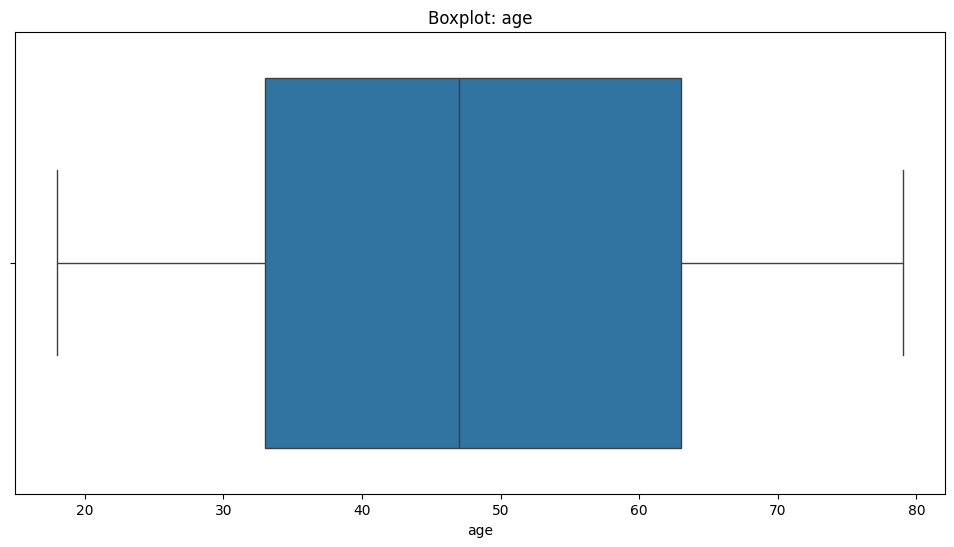

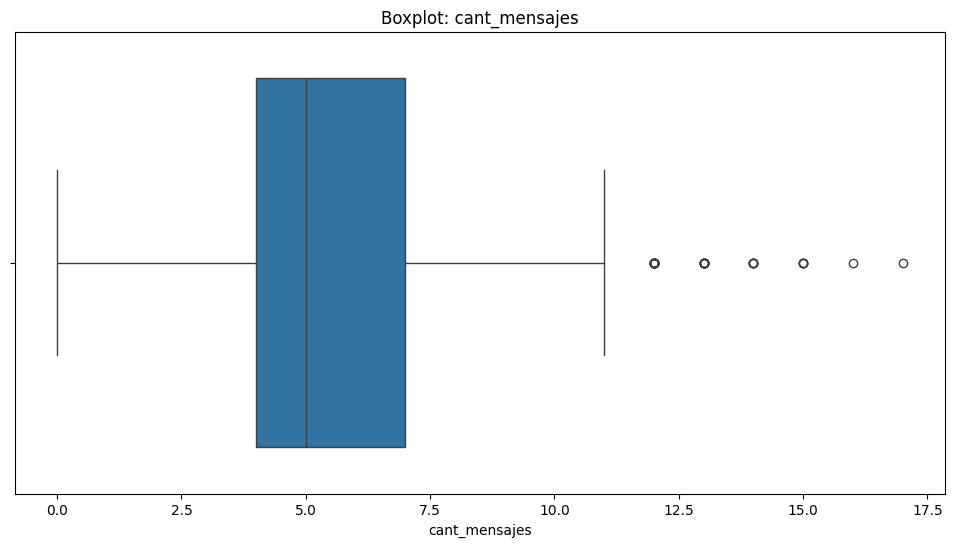

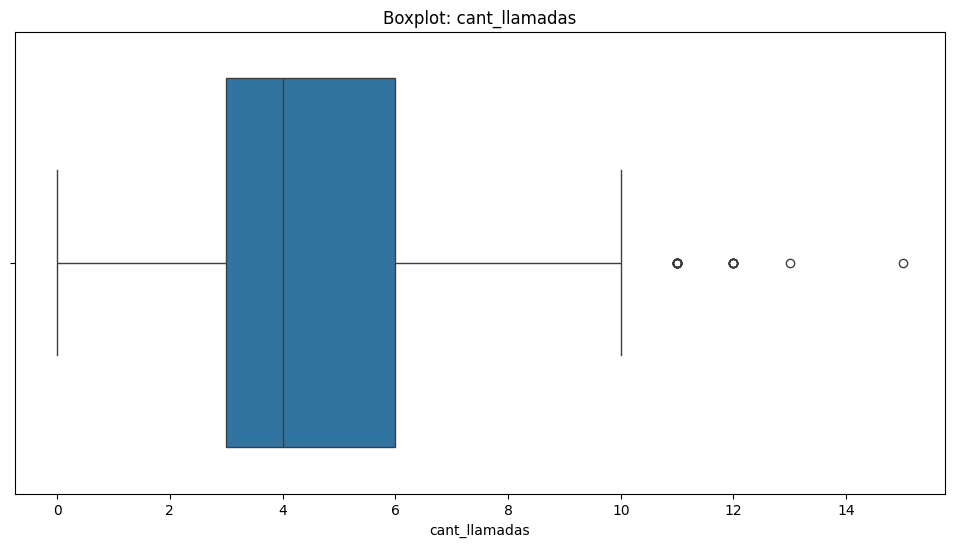

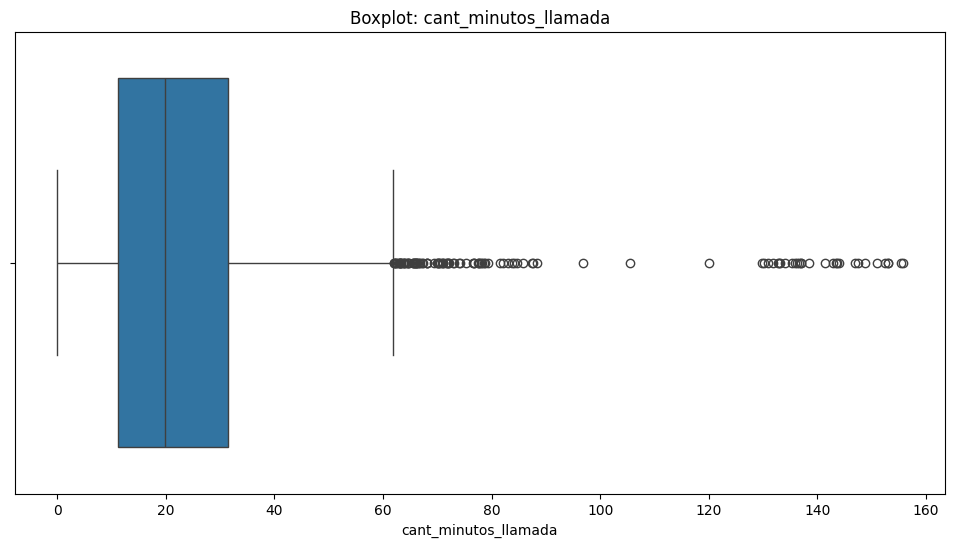

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: *No presenta outliers*
- cant_mensajes: *Presenta outliers*
- cant_llamadas: *Presenta outliers*
- cant_minutos_llamada: *Presenta outliers más marcados que el resto de las columnas*

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper=Q3 + 1.5*IQR
    print(f'Valores para {col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, upper={upper}\n')




Valores para cant_mensajes: Q1=4.0, Q3=7.0, IQR=3.0, upper=11.5

Valores para cant_llamadas: Q1=3.0, Q3=6.0, IQR=3.0, upper=10.5

Valores para cant_minutos_llamada: Q1=11.12, Q3=31.415, IQR=20.295, upper=61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? <br>
  Para poder aplicar el método IQR se debe separar los usuarios `basicos` de los `premium`, si se observa el histograma se observa que los usuarios *básicos* tienen una distribusción multimodal, mientras que los *premium* presentan una distribución picuda, es decir, normal que se puede trabajar con IQR, por como se esta solicitando el ejerccio se mantienen los outliers, si se requeire no mantener outliers se deberá trabajar con el metodo Z-score para esta columna sin tener que separar por tipo de planes.
- cant_llamadas: mantener o no outliers, porqué?<br>
  Para poder aplicar el método IQR se debe separar los usuarios `basicos` de los `premium`, si se observa el histograma se observa que los usuarios *básicos* tienen una distribusción multimodal, mientras que los *premium* presentan una distribución picuda, es decir, normal que se puede trabajar con IQR, por como se esta solicitando el ejerccio se mantienen los outliers, si se requeire no mantener outliers se deberá trabajar con el metodo Z-score para esta columna sin tener que separar por tipo de planes.
- cant_minutos_llamada: mantener o no outliers, porqué? <br>
  Dada a la distribución normal que se tinene se considera no mantener los outliers, dado que puede distorcionar como se están comportando los clientes en los minutos que usan, sin embargo, no se eliminan dado que pueden ser clientes que hacen un consumo considerado por lo que se considera capar con el valor del percentil 99.

In [ ]:
#Obtención percentil 99 de cant_minutos_llamada:

p99 = user_profile['cant_minutos_llamada'].quantile(0.99)
print('Percentil 99 de cant_minutos_llamada:', p99)

Percentil 99 de cant_minutos_llamada: 82.19759999999998


In [ ]:
#winzorización de cant_minutos_llamada:

user_profile['cant_min_llamada_winzor'] = np.clip(user_profile['cant_minutos_llamada'], None, p99)

user_profile[['cant_min_llamada_winzor', 'cant_minutos_llamada']]

,cant_min_llamada_winzor,cant_minutos_llamada
0,23.70,23.70
1,33.18,33.18
2,10.74,10.74
3,8.99,8.99
4,8.01,8.01
...,...,...
3994,21.24,21.24
3995,2.81,2.81
3996,11.34,11.34
3997,22.95,22.95


In [ ]:
user_profile[['cant_minutos_llamada', 'cant_min_llamada_winzor']].describe()

,cant_minutos_llamada,cant_min_llamada_winzor
count,3999.000000,3999.000000
mean,23.317054,22.864377
std,18.168095,15.822755
min,0.000000,0.000000
25%,11.120000,11.120000
50%,19.780000,19.780000
75%,31.415000,31.415000
max,155.690000,82.197600


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
# creación de la función
def uso (row):
    msj = row['cant_mensajes']
    llam = row['cant_llamadas']

    # manejo de valores nulos / faltantes
    if pd.isna(msj) and pd.isna(llam):
        return "Error en Datos"

    #segmentación
    if llam < 5 and msj < 5:
        return 'Bajo uso'
    elif llam < 10 and msj < 10:
        return 'Uso Medio'
    else:
        return 'Alto uso'

#aplicamos función
user_profile['grupo_uso'] = user_profile.apply(uso,axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,Uso Medio
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,Uso Medio
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def gpo_edad (row):
    edad = row['age']

    # manejo de valores nulos / faltantes
    if pd.isna(edad):
        return "Error en Datos"

    #segmentación
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

#aplicamos función
user_profile['grupo_edad'] = user_profile.apply(gpo_edad,axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,23.70,Uso Medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,33.18,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,10.74,Uso Medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,8.99,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

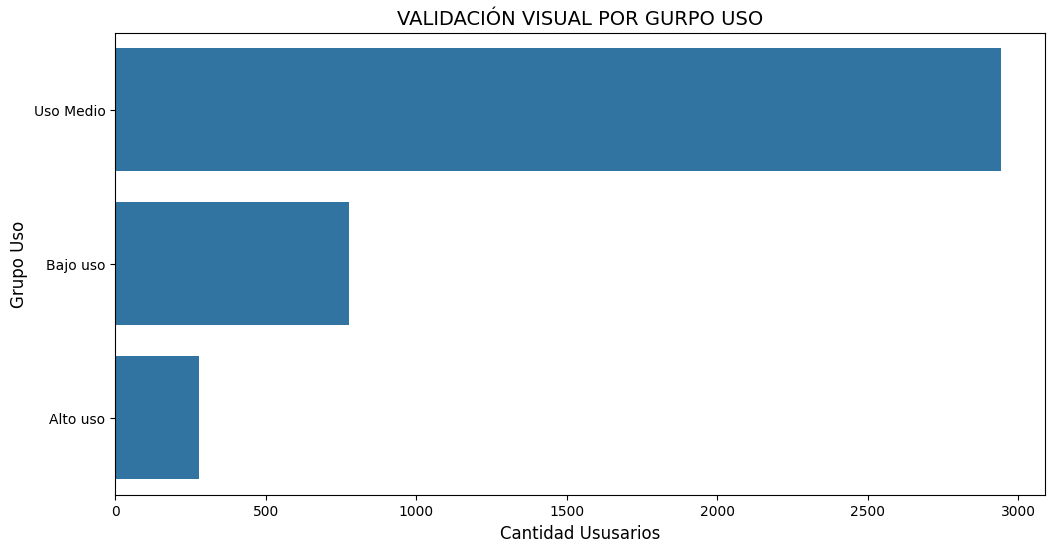

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(12,6))
sns.countplot(data=user_profile, y='grupo_uso', order=user_profile['grupo_uso'].value_counts().index)
plt.title('VALIDACIÓN VISUAL POR GURPO USO', fontsize=14)
plt.ylabel('Grupo Uso', fontsize=12)
plt.xlabel('Cantidad Ususarios', fontsize=12)
plt.show()

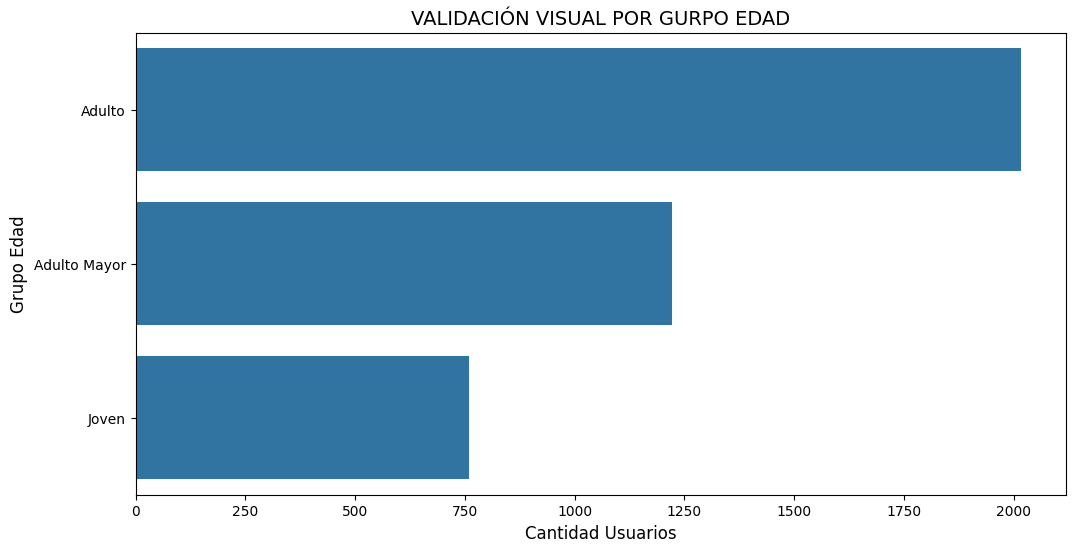

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(12,6))
sns.countplot(data=user_profile, y='grupo_edad', order=user_profile['grupo_edad'].value_counts().index)
plt.title('VALIDACIÓN VISUAL POR GURPO EDAD', fontsize=14)
plt.ylabel('Grupo Edad', fontsize=12)
plt.xlabel('Cantidad Usuarios', fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- En los dataset de *users* se encontraron el mayor porcentaje de nulos o faltantes en `churn_date` con un 88%, el siguiente fue `city` con un 11%, mientras que en *usage* nos encontramos con faltantes nulos o faltantes engañosos en las columnas `duration` y `length` debido a que dependen de la columna `type` que indica el uso y se comprueba más adelante que son del tipo **MAR**, y por último la columna `date` donde se encontró con un 0.12%.
- Encontramos con sentiles en el dataset de *users* para la columna de `age`, lo cual se manejo con la mediana, así como en en `city` donde el sentinel fue "?", el cual se camnbio por **NaN**.
- Se observo que las fechas en ambos dataset se consideraron como `string` no como datetime por lo que se realizó el cambio y permitiió que se realizará el filtro para el año que nos solicitaron revisar que es **2024**


🔍 **Segmentos por Edad**
- Entre todos los segmentos por Edad se utiliza mayormente el **Plan Básico**, encontrando que los Adultos son los que más lo utilizan.
- El **Plan Premium** es el *menos* utilizado y entre ellos se mantiene la dendencia de los Adultos que son los más tienen contratado este tipo de plan.


📊 **Segmentos por Nivel de Uso**
- El segmento de **Uso medio** tiene la mayor cantidad de usuarios entre todos los grupos de edad que tiene el dataset, seguido por el de Bajo Uso.
- En el segmento de *Alto Uso* encontramos que los Adultos son los predominantes, sin embargo se debe tomar acción para que este le sea más atractivo para los `Jovenes`


➡️ Esto sugiere que durante el periodo análizado *nungún usuario* sobrepaso los **mensajes incluidos** en su plan, por otro lado, los usuarios axtivos con Plan Básico cuentan con excedentes en los **minutos incluidos**, dando un total de 14 usuarios, y se mantiene el nivle de *Uso Medio* pero se observa que en este caso *Adulto Mayor* es el que más tiene este tipo de comportamiento seguido por *Jóven*.


💡 **Recomendaciones**
- Se comienda crear un plan intermedio entre `Básico` y `Premium` para poder captar a clientes que tienen un excedente, conforme al análisis realizado se determina que al media en excedente es de 39.94 minutos lo que implica en la facturación aproximadamente USD 3.99, se podria considerar que este plan tenga un costo de *USD 18 y contemple 250 mensajes incluidos y 300 minutos*.
- En este análisis y conforme a la información brindada no se observa el comportamiento del uso de datos para deahi determinar si una mejor oferta en datos incluidos pueda capatar a los *Jóvenes* y con ello contar con mayor cobertura de mercado.

In [ ]:
# Tabla que apoya los resultados para los insignts de Segmento Edad
pd.crosstab(user_profile['plan'], user_profile['grupo_edad'], margins=True, margins_name='Total')

grupo_edad,Adulto,Adulto Mayor,Joven,Total
plan,,,,
Basico,1324,784,486,2594
Premium,693,438,274,1405
Total,2017,1222,760,3999


In [ ]:
# Tabla que apoya los resultados para los insignts de Segmento Uso
pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'], margins=True, margins_name='Total')

grupo_uso,Alto uso,Bajo uso,Uso Medio,Total
grupo_edad,,,,
Adulto,153,364,1500,2017
Adulto Mayor,74,257,891,1222
Joven,51,157,552,760
Total,278,778,2943,3999


In [ ]:
# Filtro para cant_minutos_llamada >= 100 y siguen activos
filtro = user_profile[(user_profile['cant_minutos_llamada']>=100) & (user_profile['churn_date'].isna())]
print(filtro.shape)
filtro

(26, 14)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso,grupo_edad
85,10085,6,5,152.36,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
189,10189,9,4,155.42,Mariana,Torres,63,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
216,10216,4,6,148.76,Ana,Garcia,75,GDL,2022-03-01 03:28:29.527381846,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
226,10226,1,1,120.00,Luis,Torres,26,GDL,2022-03-03 21:11:28.672168042,Basico,NaN,82.1976,Bajo uso,Joven
349,10349,6,7,150.92,Ana,Gomez,67,GDL,2022-04-06 13:30:12.153038260,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
372,10372,7,7,143.63,Ana,Gomez,49,MTY,2022-04-12 20:39:04.186046512,Basico,NaN,82.1976,Uso Medio,Adulto
399,10399,5,4,136.24,Mateo,Gomez,70,CDMX,2022-04-20 06:05:07.876969242,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
484,10484,7,6,137.07,Ana,Gomez,45,Bogotá,2022-05-13 12:40:30.607651914,Premium,NaN,82.1976,Uso Medio,Adulto
534,10534,3,4,153.06,Carlos,Lopez,63,CDMX,2022-05-27 05:15:26.331582896,Premium,NaN,82.1976,Bajo uso,Adulto Mayor
585,10585,5,5,153.02,Ana,Gomez,68,GDL,2022-06-10 04:24:39.969992498,Premium,NaN,82.1976,Uso Medio,Adulto Mayor


In [ ]:
# Filtro para cant_minutos_llamada >= 100 & que son de plan Premium
filtrop = filtro[(filtro['cant_minutos_llamada']>=100) & (filtro['plan']== 'Premium')]
print(filtrop.shape)
filtrop


(12, 14)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso,grupo_edad
216,10216,4,6,148.76,Ana,Garcia,75,GDL,2022-03-01 03:28:29.527381846,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
399,10399,5,4,136.24,Mateo,Gomez,70,CDMX,2022-04-20 06:05:07.876969242,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
484,10484,7,6,137.07,Ana,Gomez,45,Bogotá,2022-05-13 12:40:30.607651914,Premium,NaN,82.1976,Uso Medio,Adulto
534,10534,3,4,153.06,Carlos,Lopez,63,CDMX,2022-05-27 05:15:26.331582896,Premium,NaN,82.1976,Bajo uso,Adulto Mayor
585,10585,5,5,153.02,Ana,Gomez,68,GDL,2022-06-10 04:24:39.969992498,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
1588,11589,3,4,136.55,Mariana,Gomez,64,Bogotá,2023-03-12 02:20:26.106526632,Premium,NaN,82.1976,Bajo uso,Adulto Mayor
2250,12251,8,3,143.36,Carlos,Lopez,63,<NA>,2023-09-09 08:46:05.491372848,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
2414,12415,4,5,129.75,Luis,Torres,25,Medellín,2023-10-24 06:31:03.465866472,Premium,NaN,82.1976,Uso Medio,Joven
2710,12711,8,3,132.92,Sofia,Garcia,74,Bogotá,2024-01-13 07:43:26.151537888,Premium,NaN,82.1976,Uso Medio,Adulto Mayor
2960,12961,8,4,146.92,Carlos,Lopez,28,Cali,2024-03-21 18:38:04.771192800,Premium,NaN,82.1976,Uso Medio,Joven


In [ ]:
# Filtro para cant_minutos_llamada >= 100 & que son de plan Básico &
filtrob = filtro[(filtro['cant_minutos_llamada']>=100) & (filtro['plan']== 'Basico')]
print(filtrob.shape)
filtrob

(14, 14)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso,grupo_edad
85,10085,6,5,152.36,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
189,10189,9,4,155.42,Mariana,Torres,63,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
226,10226,1,1,120.00,Luis,Torres,26,GDL,2022-03-03 21:11:28.672168042,Basico,NaN,82.1976,Bajo uso,Joven
349,10349,6,7,150.92,Ana,Gomez,67,GDL,2022-04-06 13:30:12.153038260,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
372,10372,7,7,143.63,Ana,Gomez,49,MTY,2022-04-12 20:39:04.186046512,Basico,NaN,82.1976,Uso Medio,Adulto
1303,11304,9,7,135.36,Luis,Ramirez,26,NaN,2022-12-24 01:25:20.480120032,Basico,NaN,82.1976,Uso Medio,Joven
1726,11727,7,5,133.10,Mateo,Garcia,64,Bogotá,2023-04-18 21:13:38.304576144,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
2785,12786,7,4,137.05,Mariana,Gomez,79,Cali,2024-02-02 20:35:49.737434360,Basico,NaN,82.1976,Uso Medio,Adulto Mayor
3297,13298,10,2,130.23,Mateo,Ramirez,48,GDL,2024-06-22 01:16:41.950487632,Basico,NaN,82.1976,Alto uso,Adulto
3324,13325,4,7,143.97,Carlos,Garcia,24,MTY,2024-06-29 10:42:45.641410352,Basico,NaN,82.1976,Uso Medio,Joven


In [ ]:
pd.crosstab([filtrob['grupo_edad'], filtrob['grupo_uso']], filtrob['plan'],  margins=True, margins_name='Total')

plan                    Basico  Total
grupo_edad   grupo_uso               
Adulto       Alto uso        1      1
             Uso Medio       3      3
Adulto Mayor Uso Medio       5      5
Joven        Bajo uso        1      1
             Uso Medio       4      4
Total                       14     14

In [ ]:
filtrob['excedente'] = filtrob['cant_minutos_llamada']-100
filtrob

/tmp/ipykernel_7714/573056487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtrob['excedente'] = filtrob['cant_minutos_llamada']-100


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso,grupo_edad,excedente
85,10085,6,5,152.36,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,52.36
189,10189,9,4,155.42,Mariana,Torres,63,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,55.42
226,10226,1,1,120.00,Luis,Torres,26,GDL,2022-03-03 21:11:28.672168042,Basico,NaN,82.1976,Bajo uso,Joven,20.00
349,10349,6,7,150.92,Ana,Gomez,67,GDL,2022-04-06 13:30:12.153038260,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,50.92
372,10372,7,7,143.63,Ana,Gomez,49,MTY,2022-04-12 20:39:04.186046512,Basico,NaN,82.1976,Uso Medio,Adulto,43.63
1303,11304,9,7,135.36,Luis,Ramirez,26,NaN,2022-12-24 01:25:20.480120032,Basico,NaN,82.1976,Uso Medio,Joven,35.36
1726,11727,7,5,133.10,Mateo,Garcia,64,Bogotá,2023-04-18 21:13:38.304576144,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,33.10
2785,12786,7,4,137.05,Mariana,Gomez,79,Cali,2024-02-02 20:35:49.737434360,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,37.05
3297,13298,10,2,130.23,Mateo,Ramirez,48,GDL,2024-06-22 01:16:41.950487632,Basico,NaN,82.1976,Alto uso,Adulto,30.23
3324,13325,4,7,143.97,Carlos,Garcia,24,MTY,2024-06-29 10:42:45.641410352,Basico,NaN,82.1976,Uso Medio,Joven,43.97


In [ ]:
filtrob['pago_adi']=filtrob['excedente']*0.10
filtrob['total']=filtrob['pago_adi']+12
filtrob

/tmp/ipykernel_7714/4180126023.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtrob['pago_adi']=filtrob['excedente']*0.10
/tmp/ipykernel_7714/4180126023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtrob['total']=filtrob['pago_adi']+12


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,cant_min_llamada_winzor,grupo_uso,grupo_edad,excedente,pago_adi,total
85,10085,6,5,152.36,Carlos,Ramirez,65,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,52.36,5.236,17.236
189,10189,9,4,155.42,Mariana,Torres,63,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,55.42,5.542,17.542
226,10226,1,1,120.00,Luis,Torres,26,GDL,2022-03-03 21:11:28.672168042,Basico,NaN,82.1976,Bajo uso,Joven,20.00,2.000,14.000
349,10349,6,7,150.92,Ana,Gomez,67,GDL,2022-04-06 13:30:12.153038260,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,50.92,5.092,17.092
372,10372,7,7,143.63,Ana,Gomez,49,MTY,2022-04-12 20:39:04.186046512,Basico,NaN,82.1976,Uso Medio,Adulto,43.63,4.363,16.363
1303,11304,9,7,135.36,Luis,Ramirez,26,NaN,2022-12-24 01:25:20.480120032,Basico,NaN,82.1976,Uso Medio,Joven,35.36,3.536,15.536
1726,11727,7,5,133.10,Mateo,Garcia,64,Bogotá,2023-04-18 21:13:38.304576144,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,33.10,3.310,15.310
2785,12786,7,4,137.05,Mariana,Gomez,79,Cali,2024-02-02 20:35:49.737434360,Basico,NaN,82.1976,Uso Medio,Adulto Mayor,37.05,3.705,15.705
3297,13298,10,2,130.23,Mateo,Ramirez,48,GDL,2024-06-22 01:16:41.950487632,Basico,NaN,82.1976,Alto uso,Adulto,30.23,3.023,15.023
3324,13325,4,7,143.97,Carlos,Garcia,24,MTY,2024-06-29 10:42:45.641410352,Basico,NaN,82.1976,Uso Medio,Joven,43.97,4.397,16.397


In [ ]:
filtrob[['excedente', 'pago_adi', 'total']].describe()

,excedente,pago_adi,total
count,14.000000,14.000000,14.000000
mean,38.577143,3.857714,15.857714
std,14.037795,1.403780,1.403780
min,5.540000,0.554000,12.554000
25%,33.317500,3.331750,15.331750
50%,39.945000,3.994500,15.994500
75%,49.182500,4.918250,16.918250
max,55.690000,5.569000,17.569000


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
"https://github.com/samyfs-DA/telecom-analysis"

'https://github.com/samyfs-DA/telecom-analysis'